# Constant Velocity Scenario Comparison

This notebook combines the classical EKF experiment and the trained Distributed KalmanNet workflow in one place. It compares `CEKF`, `DEKF`, and `DKN` on the same constant-velocity distance/angle tracking scenario.

In [1]:
import importlib
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "utils").exists() else NOTEBOOK_DIR.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

torch.set_default_dtype(torch.float32)

import utils.ConstantVelocityScenario as constant_velocity_scenario_module
importlib.reload(constant_velocity_scenario_module)

from utils.ClassicDistributedKalman import (
    centralized_extended_kalman_filter,
    diffusion_extended_kalman_filter_parallel_edge,
)
from utils.ConstantVelocityScenario import (
    ConstantVelocityModel,
    DistanceAngleObservation,
    build_graph_data_for_dkn,
    create_distance_based_graph,
    generate_measurements,
    generate_trajectory,
    list_experiments,
    load_config,
    load_experiment_config,
    plot_graph,
    plot_tracking_results,
    plot_trajectory_and_nodes,
    seed_everything,
)
from utils.DistributedKalmanNet import GraphKalmanProcess

/home/kfir-goldring/University/distributedKNET/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Experiment Selection

List available experiments under `save_root` and pick which one to load.  The experiment's `experiment_config_<n>.json` drives the entire comparison.

In [2]:
base_config_path = REPO_ROOT / "configs" / "const_vel_scenario_configured.json"
base_config = load_config(base_config_path)
save_root = REPO_ROOT / base_config["save_root"]

experiments = list_experiments(save_root)
if not experiments:
    raise RuntimeError(f"No experiment_* folders found under {save_root}")

print("Available experiments:")
for i, exp in enumerate(experiments, start=1):
    tag = ""
    description = ""
    try:
        ecfg = load_experiment_config(exp)
    except FileNotFoundError:
        ecfg = None
    if ecfg is not None:
        exp_title = ecfg.get("title", "")
        title_str = f' — "{exp_title}"' if exp_title else ""
        tag = f"  (train_T={ecfg.get('train_time_steps','?')}, lr={ecfg.get('learning_rate','?')}){title_str}"
        description = ecfg.get("description", "")
    print(f"  [{i}] {exp.name}{tag}")
    if description:
        print(f"      {description}")


Available experiments:
  [1] experiment_1  (train_T=20, lr=0.001)
      dt mismatch initial poc


In [3]:
EXPERIMENT = 1 # ← set this to the number printed above, then run

experiment_dir = experiments[EXPERIMENT - 1]
config_val = load_experiment_config(experiment_dir)
print(f"Loaded experiment: {experiment_dir.name}")
print(pd.Series(config_val))

seed_everything(config_val["seed"])

num_nodes = config_val["num_nodes"]
state_dimension = config_val["state_dimension"]
train_time_steps = config_val["train_time_steps"]
test_time_steps = config_val.get("test_time_steps", train_time_steps)
num_time_steps = test_time_steps
num_trials = config_val["num_trials"]
process_noise_std = config_val["process_noise_std"]
time_delta = config_val["time_delta"]
measurement_noise_values = config_val["measurement_noise_values"]

dkn_dir = experiment_dir / "DKN"
available_noise_values = [r for r in measurement_noise_values if (dkn_dir / f"r={r}.pth").exists()]
missing_noise_values = [r for r in measurement_noise_values if r not in available_noise_values]
if missing_noise_values:
    print(f"Warning: missing DKN checkpoints for r={missing_noise_values} in {dkn_dir} — skipping.")
if not available_noise_values:
    raise RuntimeError(f"No DKN checkpoints found in {dkn_dir}")
measurement_noise_values = available_noise_values

x_init = np.array(config_val["x0"], dtype=float).reshape(state_dimension, 1)
p0 = np.eye(state_dimension) * config_val["p0_scale"]

node_positions = np.array(config_val["node_positions"], dtype=float)
f_system = ConstantVelocityModel(time_delta)
h_system = DistanceAngleObservation(node_positions)
adjacency_matrix = create_distance_based_graph(
    node_positions,
    k_neighbors=config_val["k_neighbors"],
    seed=config_val["graph_seed"],
)
j_matrix = np.array(adjacency_matrix, dtype=float, copy=True)
np.fill_diagonal(j_matrix, 1.0)
node_types = h_system.node_classification[:, 0].numpy().astype(int)

plot_dir = experiment_dir / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

def get_trial_data(r_noise):
    trajectory = generate_trajectory(f_system, x_init, num_time_steps, process_noise_std)
    measurements = generate_measurements(h_system, trajectory, r_noise)
    return trajectory, measurements

print(f"\nTrain time steps: {train_time_steps}")
print(f"Test time steps:  {test_time_steps}")
plot_graph(adjacency_matrix, node_positions, title="Constant Velocity Scenario Graph")
plot_trajectory_and_nodes(node_positions, node_types, generate_trajectory(f_system, x_init, num_time_steps, process_noise_std))

Loaded experiment: experiment_1
seed                                                                       42
state_dimension                                                             4
x0                                                             [0, 50, 0, 50]
time_delta                                                               0.08
process_noise_std                                                         2.0
p0_scale                                                                 10.0
measurement_noise_values                                                [1.0]
use_dt_mismatch                                                          True
dt_mismatch_values                               [0.85, 0.9, 0.95, 1.0, 1.05]
num_nodes                                                                  10
graph_seed                                                                 42
k_neighbors                                                                 5
node_positions              [[77

RuntimeError: No DKN checkpoints found in /home/kfir-goldring/University/distributedKNET/models/kfir/experiment_1/DKN

## Single-Trial Comparison

Run one scenario and visualize the trajectory estimates from `CEKF`, `DEKF`, and `DKN` on exactly the same measurements.

In [ ]:
r_demo = 0.25 if 0.25 in measurement_noise_values else measurement_noise_values[0]
trajectory, measurements = get_trial_data(r_demo)

x_hat_cekf = centralized_extended_kalman_filter(
    measurements=measurements,
    f_system=f_system,
    h_system=h_system,
    r_array=r_demo * np.ones(num_nodes),
    q=process_noise_std,
    p0=p0,
    x0=x_init,
    time_steps=num_time_steps,
    node_num=num_nodes,
)

x_hat_dekf = diffusion_extended_kalman_filter_parallel_edge(
    measurements=measurements,
    f_system=f_system,
    h_system=h_system,
    r_array=r_demo * np.ones(num_nodes),
    q=process_noise_std,
    p0=p0,
    x0=x_init,
    j_matrix=j_matrix,
    time_steps=num_time_steps,
    node_num=num_nodes,
)

graph_data = build_graph_data_for_dkn(adjacency_matrix, h_system, trajectory, measurements)
kalman_process = GraphKalmanProcess(
    f_system,
    signal_dim=state_dimension,
    edge_features_dim=1,
    node_kalman_dim=state_dimension**2,
    edge_kalman_dim=2,
    hidden_dim=config_val["hidden_dim"],
    lr=config_val["learning_rate"],
    r_array=r_demo,
    learn_edge_kalman=config_val["learn_edge_kalman"],
    x0_scale=x_init,
)
run_name_demo = f"r={r_demo}"
example_model_path = experiment_dir / "DKN" / f"{run_name_demo}.pth"
kalman_process.load_state_dict(torch.load(example_model_path, map_location="cpu"))
kalman_process.eval()
with torch.no_grad():
    x_hat_dkn = kalman_process(graph_data).squeeze().cpu().numpy().mean(axis=1)

demo_tracking_plot_path = plot_dir / f"{run_name_demo}_tracking_comparison.png"
plot_tracking_results(
    trajectory,
    x_hat_cekf,
    x_hat_dekf=x_hat_dekf,
    x_hat_dkn=x_hat_dkn,
    node_positions=node_positions,
    node_types=node_types,
    save_path=demo_tracking_plot_path,
)

NameError: name 'measurement_noise_values' is not defined

## Monte Carlo Study

For each measurement noise level, evaluate `CEKF`, `DEKF`, and the matching trained `DKN` model on the same set of randomly generated trajectories and compare average position error.

In [ ]:
avg_error_cekf = []
avg_error_dekf = []
avg_error_dkn = []

for r_noise in measurement_noise_values:
    r_array = r_noise * np.ones(num_nodes)
    run_name = f"r={r_noise}"
    example_model_path = experiment_dir / "DKN" / f"{run_name}.pth"

    kalman_process = GraphKalmanProcess(
        f_system,
        signal_dim=state_dimension,
        edge_features_dim=1,
        node_kalman_dim=state_dimension**2,
        edge_kalman_dim=2,
        hidden_dim=config_val["hidden_dim"],
        lr=config_val["learning_rate"],
        r_array=r_noise,
        learn_edge_kalman=config_val["learn_edge_kalman"],
        x0_scale=x_init,
    )
    kalman_process.load_state_dict(torch.load(example_model_path, map_location="cpu"))
    kalman_process.eval()

    trial_errors_cekf = []
    trial_errors_dekf = []
    trial_errors_dkn = []

    for _ in tqdm(range(num_trials), desc=f"r={r_noise}"):
        trajectory, measurements = get_trial_data(r_noise)

        x_hat_cekf = centralized_extended_kalman_filter(
            measurements=measurements,
            f_system=f_system,
            h_system=h_system,
            r_array=r_array,
            q=process_noise_std,
            p0=p0,
            x0=x_init,
            time_steps=num_time_steps,
            node_num=num_nodes,
        )
        x_hat_dekf = diffusion_extended_kalman_filter_parallel_edge(
            measurements=measurements,
            f_system=f_system,
            h_system=h_system,
            r_array=r_array,
            q=process_noise_std,
            p0=p0,
            x0=x_init,
            j_matrix=j_matrix,
            time_steps=num_time_steps,
            node_num=num_nodes,
        )

        graph_data = build_graph_data_for_dkn(adjacency_matrix, h_system, trajectory, measurements)
        with torch.no_grad():
            x_hat_dkn = kalman_process(graph_data).squeeze().cpu().numpy().mean(axis=1)

        x_true = trajectory[:, 0, 0].numpy()
        y_true = trajectory[:, 2, 0].numpy()

        x_cekf = x_hat_cekf[:, 0, 0]
        y_cekf = x_hat_cekf[:, 2, 0]
        trial_errors_cekf.append(np.sqrt((x_true - x_cekf) ** 2 + (y_true - y_cekf) ** 2).mean())

        x_dekf = x_hat_dekf[:, :, 0, 0].mean(axis=1)
        y_dekf = x_hat_dekf[:, :, 2, 0].mean(axis=1)
        trial_errors_dekf.append(np.sqrt((x_true - x_dekf) ** 2 + (y_true - y_dekf) ** 2).mean())

        trial_errors_dkn.append(np.sqrt((x_true - x_hat_dkn[:, 0]) ** 2 + (y_true - x_hat_dkn[:, 2]) ** 2).mean())

    avg_error_cekf.append(np.mean(trial_errors_cekf))
    avg_error_dekf.append(np.mean(trial_errors_dekf))
    avg_error_dkn.append(np.mean(trial_errors_dkn))

results_df = pd.DataFrame(
    {
        "measurement_noise": measurement_noise_values,
        "CEKF": avg_error_cekf,
        "DEKF": avg_error_dekf,
        "DKN": avg_error_dkn,
    }
)
results_df

NameError: name 'measurement_noise_values' is not defined

Saved summary plot: /Users/inega/Python/kalmanet2/distributedKNET/models/itay/experiment_8/plots/const_vel_scenario_summary_trials=50_T=20.png


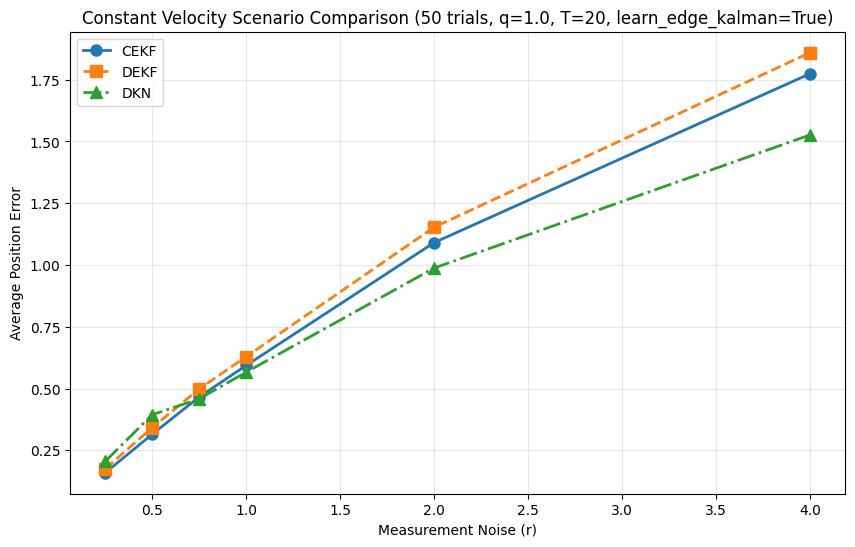

In [ ]:
summary_plot_path = plot_dir / f"const_vel_scenario_summary_trials={num_trials}_T={num_time_steps}.png"
plt.figure(figsize=(10, 6))
plt.plot(results_df["measurement_noise"], results_df["CEKF"], "o-", linewidth=2, markersize=8, label="CEKF")
plt.plot(results_df["measurement_noise"], results_df["DEKF"], "s--", linewidth=2, markersize=8, label="DEKF")
plt.plot(results_df["measurement_noise"], results_df["DKN"], "^-.", linewidth=2, markersize=8, label="DKN")
plt.xlabel("Measurement Noise (r)")
plt.ylabel("Average Position Error")
plt.title(f"Constant Velocity Scenario Comparison ({num_trials} trials, q={process_noise_std}, T={num_time_steps}, learn_edge_kalman={config_val['learn_edge_kalman']})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig(summary_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved summary plot: {summary_plot_path}")
plt.show()

## dt Mismatch Robustness

Sweep over `dt_mismatch` multipliers. Data is always generated with the **true** `time_delta`; all three filters (CEKF, DEKF, DKN) run with an internal model that uses `time_delta × ratio`. The DKN checkpoint trained at each ratio is loaded, so both the neural and the classical filters face the same model error. Expected result: EKF baselines form a U-shaped error curve centred at ratio=1; DKN stays comparatively flat.

In [ ]:
mismatch_save_root = REPO_ROOT / "models" / "kfir"  
mismatch_experiments = list_experiments(mismatch_save_root)
if not mismatch_experiments:
    raise RuntimeError(f"No experiment_* folders found under {mismatch_save_root}")

print("Available mismatch experiments:")
for i, exp in enumerate(mismatch_experiments, start=1):
    tag = ""
    try:
        ecfg = load_experiment_config(exp)
    except FileNotFoundError:
        ecfg = None
    if ecfg is not None:
        desc = ecfg.get("description", "")
        desc_str = f' — "{desc}"' if desc else ""
        tag = f"  (train_T={ecfg.get('train_time_steps','?')}){desc_str}"
    print(f"  [{i}] {exp.name}{tag}")

MISMATCH_EXPERIMENT = 1  # ← set this, then run
R_MISMATCH_EVAL = 1.0    # ← noise level to evaluate (must match a trained checkpoint)

mismatch_experiment_dir = mismatch_experiments[MISMATCH_EXPERIMENT - 1]
mismatch_config = load_experiment_config(mismatch_experiment_dir)
dt_mismatch_values = mismatch_config.get("dt_mismatch_values", [1.0])
mismatch_plot_dir = mismatch_experiment_dir / "plots"
mismatch_plot_dir.mkdir(parents=True, exist_ok=True)

print(f"\nLoaded: {mismatch_experiment_dir.name}")
print(f"dt_mismatch_values: {dt_mismatch_values}")
print(f"Evaluating at r={R_MISMATCH_EVAL}")

Available mismatch experiments:
  [1] experiment_1  (train_T=20) — "\"

Loaded: experiment_1
dt_mismatch_values: [0.85, 0.9, 0.95, 1, 1.05, 1.1, 1.15]
Evaluating at r=1.0


In [ ]:
mismatch_errors_cekf = []
mismatch_errors_dekf = []
mismatch_errors_dkn = []

r_array_mismatch = R_MISMATCH_EVAL * np.ones(num_nodes)
f_data = ConstantVelocityModel(time_delta)  # true dynamics — data always uses real dt

# Paired evaluation: pre-generate (trajectory, measurements) trials once and
# evaluate every ratio against the *same* realizations. This removes the
# trial-to-trial variance that otherwise hides the dt-mismatch signal.
paired_trials = []
for _ in range(num_trials):
    traj = generate_trajectory(f_data, x_init, num_time_steps, process_noise_std)
    meas = generate_measurements(h_system, traj, R_MISMATCH_EVAL)
    paired_trials.append((traj, meas))

for ratio in dt_mismatch_values:
    f_model_r = ConstantVelocityModel(time_delta * ratio)  # assumed (wrong) model

    model_path = mismatch_experiment_dir / "DKN" / f"r={R_MISMATCH_EVAL}_dtx{ratio}.pth"
    kalman_process_m = GraphKalmanProcess(
        f_model_r,
        signal_dim=state_dimension,
        edge_features_dim=1,
        node_kalman_dim=state_dimension**2,
        edge_kalman_dim=2,
        hidden_dim=mismatch_config["hidden_dim"],
        lr=mismatch_config["learning_rate"],
        r_array=R_MISMATCH_EVAL,
        learn_edge_kalman=mismatch_config["learn_edge_kalman"],
        x0_scale=x_init,
    )
    kalman_process_m.load_state_dict(torch.load(model_path, map_location="cpu"))
    kalman_process_m.eval()

    trial_errors_cekf_m = []
    trial_errors_dekf_m = []
    trial_errors_dkn_m = []

    for trajectory, measurements in tqdm(paired_trials, desc=f"ratio={ratio}"):
        x_hat_cekf_m = centralized_extended_kalman_filter(
            measurements=measurements,
            f_system=f_model_r,
            h_system=h_system,
            r_array=r_array_mismatch,
            q=process_noise_std,
            p0=p0,
            x0=x_init,
            time_steps=num_time_steps,
            node_num=num_nodes,
        )
        x_hat_dekf_m = diffusion_extended_kalman_filter_parallel_edge(
            measurements=measurements,
            f_system=f_model_r,
            h_system=h_system,
            r_array=r_array_mismatch,
            q=process_noise_std,
            p0=p0,
            x0=x_init,
            j_matrix=j_matrix,
            time_steps=num_time_steps,
            node_num=num_nodes,
        )

        graph_data = build_graph_data_for_dkn(adjacency_matrix, h_system, trajectory, measurements)
        with torch.no_grad():
            x_hat_dkn_m = kalman_process_m(graph_data).squeeze().cpu().numpy().mean(axis=1)

        x_true = trajectory[:, 0, 0].numpy()
        y_true = trajectory[:, 2, 0].numpy()

        x_cekf = x_hat_cekf_m[:, 0, 0]
        y_cekf = x_hat_cekf_m[:, 2, 0]
        trial_errors_cekf_m.append(np.sqrt((x_true - x_cekf) ** 2 + (y_true - y_cekf) ** 2).mean())

        x_dekf = x_hat_dekf_m[:, :, 0, 0].mean(axis=1)
        y_dekf = x_hat_dekf_m[:, :, 2, 0].mean(axis=1)
        trial_errors_dekf_m.append(np.sqrt((x_true - x_dekf) ** 2 + (y_true - y_dekf) ** 2).mean())

        trial_errors_dkn_m.append(np.sqrt((x_true - x_hat_dkn_m[:, 0]) ** 2 + (y_true - x_hat_dkn_m[:, 2]) ** 2).mean())

    mismatch_errors_cekf.append(np.mean(trial_errors_cekf_m))
    mismatch_errors_dekf.append(np.mean(trial_errors_dekf_m))
    mismatch_errors_dkn.append(np.mean(trial_errors_dkn_m))

mismatch_results_df = pd.DataFrame({
    "dt_mismatch": dt_mismatch_values,
    "CEKF": mismatch_errors_cekf,
    "DEKF": mismatch_errors_dekf,
    "DKN": mismatch_errors_dkn,
})

mismatch_summary_path = mismatch_plot_dir / f"mismatch_robustness_r={R_MISMATCH_EVAL}_trials={num_trials}.png"
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(mismatch_results_df["dt_mismatch"], mismatch_results_df["CEKF"], "o-", linewidth=2, markersize=8, label="CEKF")
ax.plot(mismatch_results_df["dt_mismatch"], mismatch_results_df["DEKF"], "s--", linewidth=2, markersize=8, label="DEKF")
ax.plot(mismatch_results_df["dt_mismatch"], mismatch_results_df["DKN"], "^-.", linewidth=2, markersize=8, label="DKN")
ax.axvline(x=1.0, color="gray", linestyle=":", linewidth=1.5, label="No mismatch (ratio=1)")
ax.set_xlabel("dt mismatch ratio")
ax.set_ylabel("Average Position Error")
ax.set_title(f"dt Mismatch Robustness (r={R_MISMATCH_EVAL}, {num_trials} trials, q={process_noise_std}, T={num_time_steps})")
ax.grid(True, alpha=0.3)
ax.legend()
fig.savefig(mismatch_summary_path, dpi=200, bbox_inches="tight")
print(f"Saved: {mismatch_summary_path}")
plt.show()

mismatch_results_df